# 02 — Modelling

Exports the study's data as CSV, then trains four model families on a
chronological 80/20 split and explains what they used.

Every step calls the same modules as `scripts/run_models.py`, so the numbers
here cannot drift away from the dashboard's.

**Prerequisite:** run `python -m scripts.run_data` first.

In [1]:
import sys
from pathlib import Path

# Let a notebook living in notebooks/ see the src package.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import PROCESSED_DIR, RAW_DIR, load_config
from src.utils import load_table

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (11, 4)

cfg = load_config()
TOP_N = cfg["features"]["top_n"]
SET_NAME = cfg["features"]["best_set"]

print(f"top_n={TOP_N}  feature set={SET_NAME}  test_ratio={cfg['split']['test_ratio']}")

top_n=10  feature set=C  test_ratio=0.2


## 1. Load the prepared tables

In [2]:
dataset = load_table(PROCESSED_DIR / "dataset.parquet")
top10 = load_table(PROCESSED_DIR / "top10_daily.parquet")
universe = load_table(PROCESSED_DIR / "universe.parquet")

for frame in (dataset, top10):
    frame["date"] = pd.to_datetime(frame["date"])

# Raw closes, the series every market cap is built from.
prices = pd.read_parquet(RAW_DIR / "constituent_prices.parquet")
prices.index = pd.to_datetime(prices.index)

print(f"dataset  {dataset.shape[0]:,} rows x {dataset.shape[1]} cols")
print(f"top10    {top10.shape[0]:,} rows")
print(f"prices   {prices.shape[0]:,} dates x {prices.shape[1]} tickers")

dataset  2,514 rows x 22 cols


top10    2,514 rows
prices   2,514 dates x 503 tickers


## 2. Export the CSVs

Three files. The first is the one worth having: it carries the daily ranking
**and** the closing price behind each slot, in long form, so one row is one
company on one day.

In [3]:
value_cols = [f"x{i}" for i in range(1, TOP_N + 1)]
name_cols = [f"name_{i}" for i in range(1, TOP_N + 1)]
company_cols = [f"company_{i}" for i in range(1, TOP_N + 1)]

# Slots are rank positions, so the wide table is unpivoted into one row per
# (day, rank) before the close price is joined back on.
ranking = pd.concat(
    [
        pd.DataFrame({
            "date": top10["date"],
            "rank": rank,
            "ticker": top10[name_col],
            "company": top10[company_col],
            "market_cap_bn": top10[value_col],
        })
        for rank, (value_col, name_col, company_col)
        in enumerate(zip(value_cols, name_cols, company_cols), start=1)
    ],
    ignore_index=True,
).dropna(subset=["ticker"])

# Close price for the ticker that actually held the slot that day.
long_prices = (
    prices.rename_axis("date")
    .reset_index()
    .melt(id_vars="date", var_name="ticker", value_name="close")
)
ranking = ranking.merge(long_prices, on=["date", "ticker"], how="left")
ranking = ranking.sort_values(["date", "rank"]).reset_index(drop=True)
ranking = ranking[["date", "rank", "ticker", "company", "close", "market_cap_bn"]]

print(f"{len(ranking):,} rows  |  missing close: {int(ranking['close'].isna().sum())}")
ranking.head(12)

25,140 rows  |  missing close: 0


,date,rank,ticker,company,close,market_cap_bn
0,2016-01-04,1,GOOGL,Alphabet Inc. (Class A),37.972000,464.395087
1,2016-01-04,2,GOOG,Alphabet Inc. (Class C),37.091999,453.632731
2,2016-01-04,3,MSFT,Microsoft,54.799999,406.919887
3,2016-01-04,4,AAPL,Apple Inc.,26.337500,384.374210
4,2016-01-04,5,AMZN,Amazon,31.849501,343.538701
5,2016-01-04,6,XOM,ExxonMobil,77.459999,318.508697
6,2016-01-04,7,BRK-B,Berkshire Hathaway,130.750000,279.897806
7,2016-01-04,8,META,Meta Platforms,102.220001,260.406089
8,2016-01-04,9,JNJ,Johnson & Johnson,100.480003,242.146619
9,2016-01-04,10,VZ,Verizon,45.869999,190.579534


In [4]:
# Only the tickers that ever held a top-ten slot. The other 480 never enter the
# study, and carrying them would turn a 1.5 MB file into a 30 MB one.
top_tickers = sorted(ranking["ticker"].unique())
close_wide = prices[top_tickers].rename_axis("date").reset_index()

index_close = (
    dataset[["date", "baseline_naive"]]
    .rename(columns={"baseline_naive": "close"})
    .dropna()
)

exports = {
    "top10_ranking_daily.csv": ranking,
    "close_prices_top10.csv": close_wide,
    "index_close.csv": index_close,
}

for filename, frame in exports.items():
    path = PROCESSED_DIR / filename
    frame.to_csv(path, index=False, encoding="utf-8")
    size_mb = path.stat().st_size / 1e6
    print(f"{filename:28} {len(frame):>7,} rows x {frame.shape[1]:>2} cols   {size_mb:5.2f} MB")

print(f"\n{len(top_tickers)} tickers held a top-{TOP_N} slot at some point:")
print(", ".join(top_tickers))

top10_ranking_daily.csv       25,140 rows x  6 cols    1.76 MB


close_prices_top10.csv         2,514 rows x 24 cols    1.07 MB
index_close.csv                2,514 rows x  2 cols    0.07 MB

23 tickers held a top-10 slot at some point:
AAPL, AMZN, AVGO, BA, BRK-B, CVX, GOOG, GOOGL, INTC, JNJ, JPM, LLY, META, MSFT, NVDA, PG, T, TSLA, UNH, V, VZ, WMT, XOM


In [5]:
# Sanity check the export rather than trusting it: market cap must equal
# shares x close, which is how the pipeline built it in the first place.
shares = universe.set_index("ticker")["shares"]
check = ranking.dropna(subset=["close"]).copy()
check["implied"] = check["ticker"].map(shares) * check["close"] / 1e9
error = (check["implied"] - check["market_cap_bn"]).abs()

print(f"rows checked      {len(check):,}")
print(f"max abs error     {error.max():.6f} bn USD")
assert error.max() < 1e-6, "close price and market cap disagree"
print("\nmarket_cap_bn == shares x close for every exported row")

rows checked      25,140
max abs error     0.000000 bn USD

market_cap_bn == shares x close for every exported row


## 3. Build the modelling frame and split it

Feature set C at N = 10, then a chronological 80/20 cut. The tail block is the
test set and nothing about it reaches a model.

In [6]:
from src.features.build_features import finalise, select_feature_set
from src.models.split import chronological_split

macro_cols = [c for c in dataset.columns
              if c in set(cfg["data"]["fred_series"]) | {"gold_return"}]
reserved = set(value_cols) | set(macro_cols) | {"date", "target", "baseline_naive"}
trend_cols = [c for c in dataset.columns if c not in reserved]

feature_cols = select_feature_set(dataset, SET_NAME, TOP_N, trend_cols, macro_cols, cfg)
X, y, dates, baseline = finalise(dataset, feature_cols)

train_idx, test_idx = chronological_split(dates, cfg)
X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

base = baseline.iloc[test_idx].to_numpy(dtype="float64")
truth = y_test.to_numpy(dtype="float64")

train_max = float(y_train.max())
above = float((truth > train_max).mean() * 100)

print(f"features   {len(feature_cols)} (set {SET_NAME})")
print(f"train      {len(X_train):,} rows  {dates.iloc[train_idx[0]].date()} -> {dates.iloc[train_idx[-1]].date()}")
print(f"test       {len(X_test):,} rows  {dates.iloc[test_idx[0]].date()} -> {dates.iloc[test_idx[-1]].date()}")
print(f"\ntrain max  {train_max:,.1f}")
print(f"test max   {truth.max():,.1f}")
print(f"test rows above the training maximum: {above:.1f}%")

2026-09-04 15:30:18 | INFO     | src.features.build_features:146 | Dataset finalised: 2514 -> 2493 rows, 19 features (2016-02-02 to 2025-12-30)


2026-09-04 15:30:18 | INFO     | src.models.split:117 | Chronological split | train 1994 rows (2016-02-02 to 2024-01-03) | test 499 rows (2024-01-04 to 2025-12-30)


features   19 (set C)
train      1,994 rows  2016-02-02 -> 2024-01-03
test       499 rows  2024-01-04 -> 2025-12-30

train max  4,796.6
test max   6,932.0
test rows above the training maximum: 98.2%


That last number is the whole experiment. Almost the entire test block is a new
high, and three of the four families cannot return a value above their training
range at all — so what follows measures the extrapolation ceiling, not fit.

## 4. Train the four families

AutoGluon is given `model.time_limit` seconds, so this cell takes a few minutes.

In [7]:
from src.models.evaluate import directional_accuracy, evaluate_with_baseline
from src.models.zoo import fit_all

fitted = fit_all(X_train, y_train, cfg)
print(f"\nfitted: {', '.join(m.name for m in fitted)}")

2026-09-04 15:30:19 | INFO     | src.models.zoo:325 | === Fitting AutoGluon on 1994 rows ===


2026-09-04 15:30:32 | INFO     | src.models.zoo:325 | === Fitting XGBoost on 1994 rows ===


2026-09-04 15:30:33 | INFO     | src.models.zoo:325 | === Fitting SVR on 1994 rows ===


2026-09-04 15:30:33 | INFO     | src.models.zoo:325 | === Fitting LSTM on 1994 rows ===


2026-09-04 15:30:45 | INFO     | src.models.zoo:277 | LSTM early stop at epoch 28 (val MSE 0.02897)



fitted: AutoGluon, XGBoost, SVR, LSTM


In [8]:
rows, prediction_frames = [], []

for model in fitted:
    preds = model.predict(X_test)

    metrics = evaluate_with_baseline(truth, preds, base)
    metrics["directional_accuracy"] = directional_accuracy(truth, preds, base)
    metrics["model"] = model.name
    metrics["pred_max"] = float(preds.max())
    metrics["shortfall"] = float(truth.max() - preds.max())
    rows.append(metrics)

    prediction_frames.append(pd.DataFrame({
        "date": dates.iloc[test_idx].to_numpy(),
        "model": model.name,
        "actual": truth,
        "predicted": preds,
        "baseline": base,
    }))

scores = pd.DataFrame(rows).sort_values("mae").reset_index(drop=True)
predictions = pd.concat(prediction_frames, ignore_index=True)

scores[["model", "mae", "rmse", "mape", "r2", "skill_mae",
        "directional_accuracy", "pred_max", "shortfall"]].round(3)

,model,mae,rmse,mape,r2,skill_mae,directional_accuracy,pred_max,shortfall
0,AutoGluon,940.845,1044.783,15.539,-2.371,24.646,0.425,5133.300,1798.750
1,LSTM,978.267,1094.748,16.128,-2.701,25.626,0.425,4971.173,1960.877
2,XGBoost,1147.154,1276.861,18.933,-4.035,30.050,0.427,4760.450,2171.600
3,SVR,2181.892,2340.906,36.385,-15.923,57.156,0.425,4685.733,2246.317


`skill_mae` is the model's error divided by the naive "tomorrow equals today"
error. Below 1.0 would beat doing nothing; none of these come close.

The interesting column is `shortfall` — the actual high minus the model's
highest prediction. It ranks the models in the same order as MAE does.

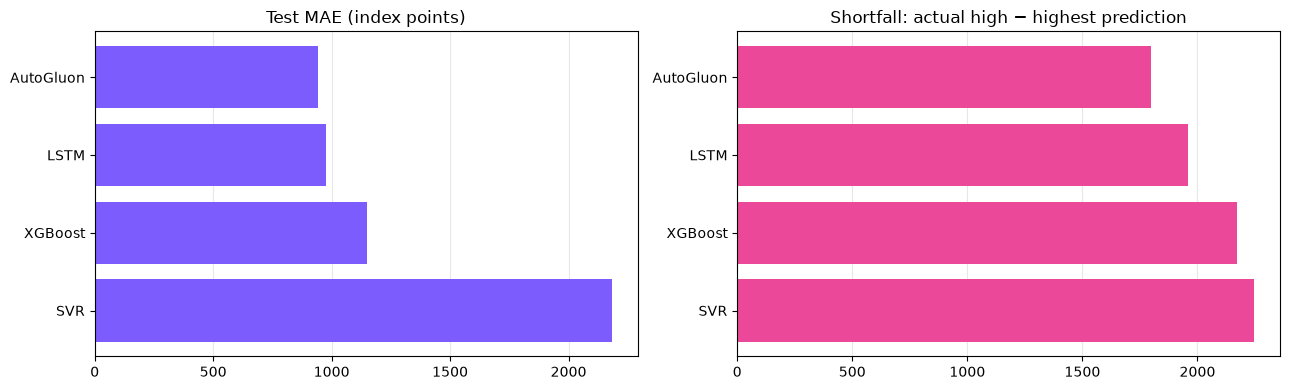

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].barh(scores["model"], scores["mae"], color="#7C5CFC")
axes[0].set_title("Test MAE (index points)")
axes[0].invert_yaxis()

axes[1].barh(scores["model"], scores["shortfall"], color="#EC4899")
axes[1].set_title("Shortfall: actual high − highest prediction")
axes[1].invert_yaxis()

for ax in axes:
    ax.grid(axis="x", alpha=0.3)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

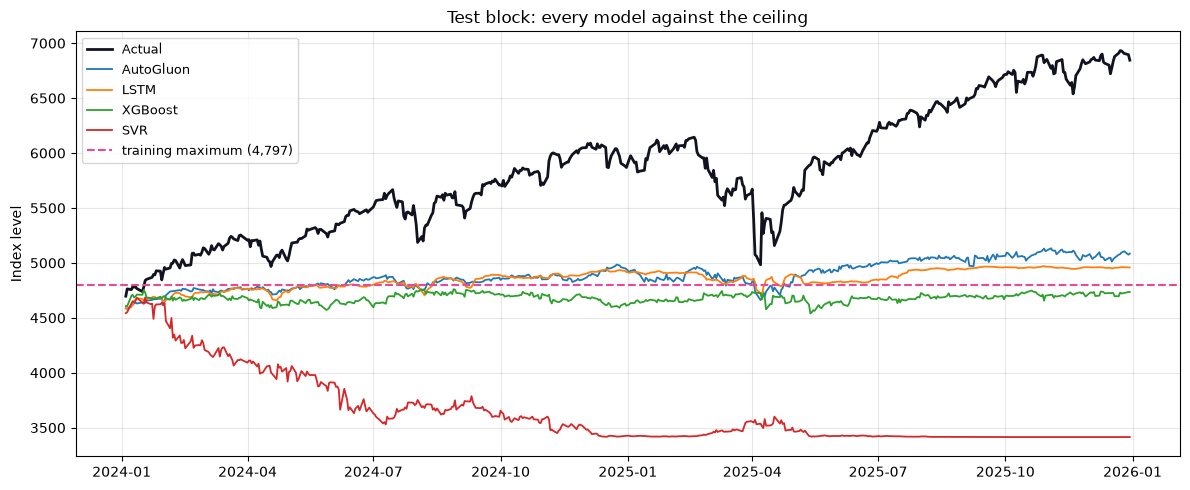

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

first = predictions[predictions["model"] == scores["model"].iloc[0]]
ax.plot(first["date"], first["actual"], lw=2, color="#111320", label="Actual")

for model in scores["model"]:
    block = predictions[predictions["model"] == model]
    ax.plot(block["date"], block["predicted"], lw=1.3, label=model)

ax.axhline(train_max, ls="--", color="#EC4899",
           label=f"training maximum ({train_max:,.0f})")

ax.set_title("Test block: every model against the ceiling")
ax.set_ylabel("Index level")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 5. Feature importance

Permutation importance works on any model, so it is the only measure comparable
across all four. SHAP decomposes individual predictions and is exact on the tree
model.

In [11]:
from src.models.explain import permutation_importance, shap_values

repeats = cfg["explain"]["permutation_repeats"]
seed = cfg["project"]["random_state"]

importance = pd.concat(
    [permutation_importance(m, X_test, y_test, repeats=repeats, seed=seed)
     for m in fitted],
    ignore_index=True,
)

pivot = importance.pivot_table(index="feature", columns="model",
                               values="importance_pct", aggfunc="mean")
pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index].round(2).head(12)

2026-09-04 15:30:48 | INFO     | src.models.explain:67 | AutoGluon | top features by permutation importance: share_1, x10, hhi, mom_20, T10Y2Y


2026-09-04 15:30:50 | INFO     | src.models.explain:67 | XGBoost | top features by permutation importance: mom_20, ma_ratio_20, share_1, T10Y2Y, DGS10


2026-09-04 15:30:53 | INFO     | src.models.explain:67 | SVR | top features by permutation importance: x10, x8, x9, x7, x3


2026-09-04 15:30:56 | INFO     | src.models.explain:67 | LSTM | top features by permutation importance: x10, share_1, T10Y2Y, hhi, DGS10


model,AutoGluon,LSTM,SVR,XGBoost
feature,,,,
x10,0.02,1.67,4.03,-0.00
x7,0.00,0.01,2.57,0.00
x9,0.00,-0.26,2.69,0.00
x3,-0.00,-0.27,2.19,0.02
x8,0.00,-1.35,2.93,-0.00
x6,-0.00,-0.79,1.88,0.01
x4,0.00,-0.43,1.43,-0.00
share_1,0.03,0.14,0.37,0.04
T10Y2Y,0.01,0.05,0.37,0.03


In [12]:
worst = importance["importance_pct"].max()
top = importance.nlargest(1, "importance").iloc[0]

print(f"largest effect any feature has on any model: {worst:.2f}% of its baseline MAE")
print(f"  ({top['model']} / {top['feature']}: MAE {top['baseline_mae']:,.2f} -> {top['permuted_mae']:,.2f})")
print()
print("Permutation importance is near zero here, and that is the result rather")
print("than a bug. The error is made almost entirely of the gap between where a")
print("model can reach and where the index went, so shuffling one column cannot")
print("move it. A model that is failing structurally has no informative")
print("permutation ranking to read.")

largest effect any feature has on any model: 4.03% of its baseline MAE
  (SVR / x10: MAE 2,181.89 -> 2,269.78)

Permutation importance is near zero here, and that is the result rather
than a bug. The error is made almost entirely of the gap between where a
model can reach and where the index went, so shuffling one column cannot
move it. A model that is failing structurally has no informative
permutation ranking to read.


2026-09-04 15:30:58 | INFO     | src.models.explain:115 | SHAP computed on 400 rows | top: x9, x4, x10, x5, x2


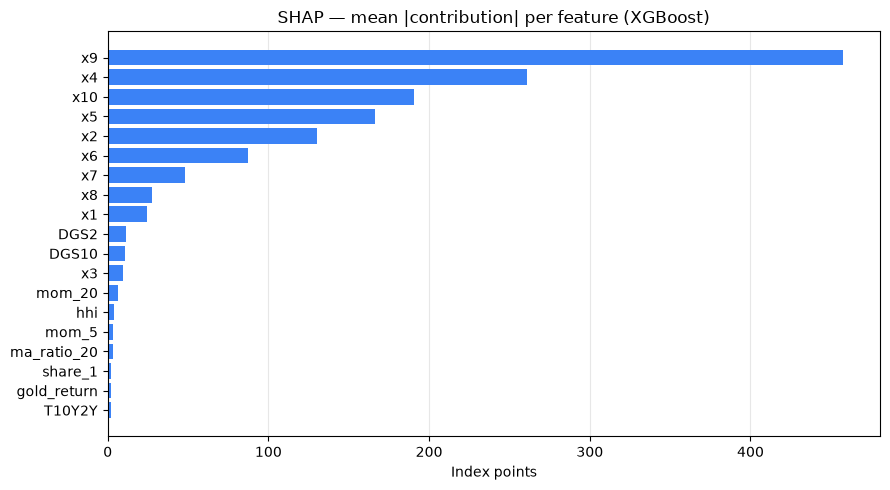

,feature,mean_abs_shap,mean_shap,base_value
0,x9,457.720001,457.720001,3276.13
1,x4,261.230011,261.230011,3276.13
2,x10,190.509995,190.509995,3276.13
3,x5,166.130005,166.130005,3276.13
4,x2,130.130005,130.130005,3276.13
5,x6,87.540001,87.540001,3276.13
6,x7,47.810001,47.810001,3276.13
7,x8,27.490000,27.490000,3276.13


In [13]:
tree = next(m for m in fitted if m.name == "XGBoost")
shap_long, shap_summary = shap_values(
    tree, X_test, sample=cfg["explain"]["shap_sample"], seed=seed
)

fig, ax = plt.subplots(figsize=(9, 5))
ranked = shap_summary.sort_values("mean_abs_shap")
ax.barh(ranked["feature"], ranked["mean_abs_shap"], color="#3B82F6")
ax.set_title("SHAP — mean |contribution| per feature (XGBoost)")
ax.set_xlabel("Index points")
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

shap_summary.head(8).round(2)

SHAP does rank the features, and it does not put the largest constituent first.
Middle slots lead it, which is the same conclusion the Spearman analysis reaches
from the other direction: how much a company weighs says little about how much
the model leans on its slot.

## Summary

In [14]:
best = scores.iloc[0]

print("CSV written to data/processed/")
for filename, frame in exports.items():
    print(f"  {filename:28} {len(frame):>7,} rows")

print(f"\nSplit    train {len(X_train):,} / test {len(X_test):,}"
      f"  (cut at {dates.iloc[test_idx[0]].date()})")
print(f"         {above:.1f}% of the test block sits above the training maximum")

print(f"\nBest     {best['model']}  MAE {best['mae']:,.1f}"
      f"  R2 {best['r2']:.2f}  skill {best['skill_mae']:.1f}x")
print(f"Worst    {scores.iloc[-1]['model']}  MAE {scores.iloc[-1]['mae']:,.1f}")
print(f"\nEvery model loses to the naive forecast, by"
      f" {scores['skill_mae'].min():.0f}x to {scores['skill_mae'].max():.0f}x.")
print("The MAE ranking is the ranking of how far each model reaches past its")
print("training maximum, which is what this split actually measures.")

CSV written to data/processed/
  top10_ranking_daily.csv       25,140 rows
  close_prices_top10.csv         2,514 rows
  index_close.csv                2,514 rows

Split    train 1,994 / test 499  (cut at 2024-01-04)
         98.2% of the test block sits above the training maximum

Best     AutoGluon  MAE 940.8  R2 -2.37  skill 24.6x
Worst    SVR  MAE 2,181.9

Every model loses to the naive forecast, by 25x to 57x.
The MAE ranking is the ranking of how far each model reaches past its
training maximum, which is what this split actually measures.


The forecasting result is not the answer to the research question — see
`01_eda.ipynb` section 5 and the Explanatory Power page for the half these
scores do not address. Within any single year the top ten explain the index
almost completely; what they cannot do is carry that relationship forward, and
the naive forecast is handed today's index level while these models are not.